# Operations, Monitoring & Evidence 
## Stage 4 · serve → containerise → automate → monitor → retrain → govern

- Each stage lists its **sub-tasks as a checklist**
- Implement reusable logic in `app.py`, `src/monitoring.py` and `src/retrain.py`.

**File ownership** —
- *Provided:* `src/generate_current_batch.py`, `src/evaluate.py`, `tests/`, `Dockerfile`, `.github/workflows/ci.yml`, `requirements.txt`
- *You create/extend:* `app.py`, `src/monitoring.py`, `src/retrain.py` and the cells below. 
- Run after the Stage-3 notebook.

## Stage 4.1 — API Deployment

- **4.1.1 — FastAPI inference service (/predict + /health + validation) [3]** *(graded from `app.py`)* — POST `/predict` (probability + label) with request validation + missing-field handling, and GET `/health`.
- **4.1.2 — Live request/response demonstrated in-notebook [2]** *(graded from this notebook)* — call `/health` and `/predict` via `fastapi.testclient.TestClient` and show the JSON.

In [2]:
# 4.1.1 (app.py): FastAPI with GET /health + POST /predict, loading the model from
#   artifacts/registry, with request validation + missing-field handling.
# 4.1.2 (here): use TestClient to call /health and /predict; show the responses.
import json, subprocess
from pathlib import Path
import pandas as pd
from fastapi.testclient import TestClient

import config as cfg
import app as app_module

client = TestClient(app_module.app)

# --- GET /health ---
health = client.get("/health")
print("GET /health ->", health.status_code, json.dumps(health.json()))

# --- POST /predict on a full encounter ---
ART = Path("artifacts")
cols = json.loads((ART / "input_columns.json").read_text())
row = pd.read_csv(ART / "reference_sample.csv")[cols].iloc[0]
payload = json.loads(row.to_json())      # numpy scalars -> native, NaN -> null

response = client.post("/predict", json={"features": payload})
print(f"\nPOST /predict ({len(payload)}/{len(cols)} fields) ->", response.status_code)
print(json.dumps(response.json(), indent=2))

# --- missing-field handling: only 5 of 39 fields ---
partial = {key: payload[key] for key in list(payload)[:5]}
r2 = client.post("/predict", json={"features": partial})
print(f"\nPartial payload ({len(partial)}/{len(cols)} fields) ->", r2.status_code, r2.json())

# --- request validation: empty dict must be rejected ---
r3 = client.post("/predict", json={"features": {}})
print("\nEmpty payload ->", r3.status_code, "(422 = validation rejected)")

GET /health -> 200 {"status": "ok", "model_loaded": true}

POST /predict (39/39 fields) -> 200
{
  "readmission_probability": 0.4973,
  "readmitted_30d": 0,
  "threshold": 0.5
}

Partial payload (5/39 fields) -> 200 {'readmission_probability': 0.3489, 'readmitted_30d': 0, 'threshold': 0.5}

Empty payload -> 422 (422 = validation rejected)


## Stage 4.2 — Containerisation

- **4.2.1 — Valid Dockerfile [2]** — `FROM python`, installs `libgomp1` (XGBoost), `pip install -r requirements.txt`, `CMD uvicorn`.
- **4.2.2 — Build/run evidence [2]** — a `docker build` log excerpt/screenshot + a sample `curl` response from the running container.

In [8]:
# 4.2.1: print your Dockerfile (Path('Dockerfile').read_text()).
print(Path("Dockerfile").read_text())

# 4.2.2: include build/run evidence (build screenshot/log + sample curl response).
#       (Remember libgomp1 is required for XGBoost in the image.)


# Hospital Readmission Prediction — inference service
FROM python:3.11-slim

# libgomp1 is required by xgboost at runtime
RUN apt-get update && apt-get install -y --no-install-recommends libgomp1 \
    && rm -rf /var/lib/apt/lists/*

WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py config.py ./
COPY src ./src
COPY artifacts ./artifacts

EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]




* curl -s localhost:8000/health

{"status":"ok","model_loaded":true}%

* curl -s -X POST localhost:8000/predict -H 'Content-Type: application/json' \
  -d '{"features": {"age": 75.0, "time_in_hospital": 5, "num_medications": 18, "number_inpatient": 2, "diag_1": "Circulatory"}}'

{"readmission_probability":0.6312,"readmitted_30d":1,"threshold":0.5}



## Stage 4.3 — CI/CD Automation

- **4.3.1 — GitHub Actions workflow (install deps + run pytest) [3]** — installs dependencies and runs the test suite on push/PR (ideally also validates the Docker build).
- **4.3.2 — Passing-test evidence [2]** — pytest output run here AND/OR a screenshot of a green Actions run.

In [17]:
# 4.3.1: print your .github/workflows/ci.yml.
print(Path(".github/workflows/ci.yml").read_text())
print("=" * 70)

# 4.3.2: run the test suite here (subprocess pytest) AND include a green-run screenshot.
result = subprocess.run(["pytest", "tests/", "-q"], capture_output=True, text=True)
print(result.stdout)


name: CI

on:
  push:
    branches: [main]
  pull_request:
    branches: [main]

jobs:
  test:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.12"
          cache: pip

      - name: Install system deps
        run: sudo apt-get update && sudo apt-get install -y --no-install-recommends libgomp1

      - name: Install Python deps
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt

      - name: Run tests
        run: pytest tests/ -q

  docker:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - name: Build image
        run: docker build -t readmission-api:ci .
      - name: Smoke-test the container
        run: |
          docker run -d --rm -p 8000:8000 --name api readmission-api:ci
          for i in $(seq 1 30); do
            curl -sf localhost:8000/health && break || sl

## Stage 4.4 — Monitoring & Drift Detection

Implement `run_monitoring()` in `src/monitoring.py`.

- **4.4.1 — Feature drift (Evidently, reference vs current) [2]** — run an Evidently `DataDriftPreset` (reference vs current batch); summarise + visualise.
- **4.4.2 — Prediction drift (PSI on scores) + interpretation [2]** — compute PSI on model scores and interpret (prediction drift can exceed feature-level drift).

/Users/junghoona/Projects/hospital-readmission-prediction/src/data_prep.py:24: DtypeWarning:

Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.



wrote current_batch.csv (5000 rows) with injected drift


/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10178: RuntimeWarning:

divide by zero encountered in vecdot

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10178: RuntimeWarning:

overflow encountered in vecdot

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10178: RuntimeWarning:

invalid value encountered in vecdot

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10178: RuntimeWarning:

divide by zero encountered in vecdot

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10178: RuntimeWarning:

overflow encountered in vecdot

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/scipy/stats/_stats_p

{
  "n_columns": 39,
  "n_drifted_columns": 6,
  "share_drifted": 0.1538,
  "dataset_drift": false,
  "drifted_columns": [
    "age",
    "time_in_hospital",
    "num_medications",
    "service_utilization",
    "number_inpatient",
    "diag_1"
  ],
  "prediction_psi": 0.2575,
  "ref_mean_score": 0.4702,
  "cur_mean_score": 0.5311
}

Feature drift : 6/39 (15.4%) | dataset_drift=False
Drifted       : ['age', 'time_in_hospital', 'num_medications', 'service_utilization', 'number_inpatient', 'diag_1']
Prediction PSI: 0.2575


/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: 

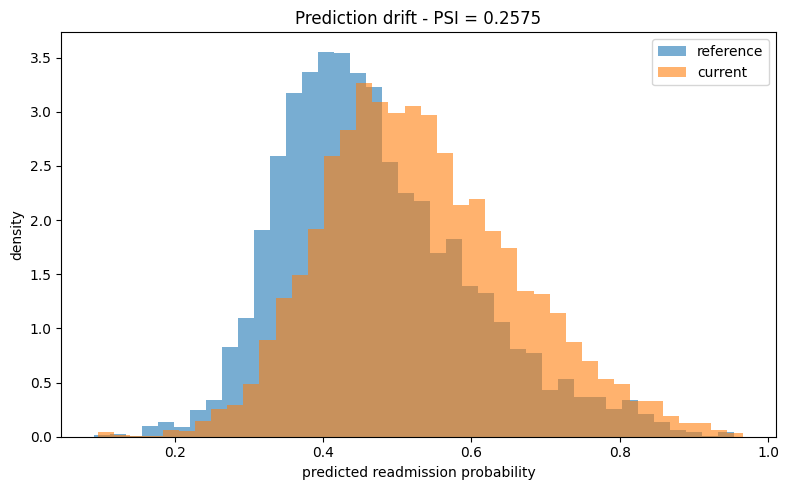

In [18]:
import matplotlib.pyplot as plt, joblib
from src import generate_current_batch, monitoring

# 4.4.1: generate a current batch (src.generate_current_batch); run Evidently feature drift.
generate_current_batch.main()           # simulate a post-deployment batch with drift
summary = monitoring.run_monitoring()   # writes drift_report.html + drift_summary.json

# 4.4.2: compute prediction PSI on model scores; summarise, plot and interpret.
print(f"\nFeature drift : {summary['n_drifted_columns']}/{summary['n_columns']} "
      f"({summary['share_drifted']:.1%}) | dataset_drift={summary['dataset_drift']}")
print(f"Drifted       : {summary['drifted_columns']}")
print(f"Prediction PSI: {summary['prediction_psi']}")

model = joblib.load("artifacts/best_model.pkl")
cols = json.loads(Path("artifacts/input_columns.json").read_text())
ref = pd.read_csv("artifacts/reference_sample.csv")
cur = pd.read_csv("artifacts/current_batch.csv")[ref.columns]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(model.predict_proba(ref[cols])[:, 1], bins=40, alpha=.6, density=True, label="reference")
ax.hist(model.predict_proba(cur[cols])[:, 1], bins=40, alpha=.6, density=True, label="current")
ax.set_xlabel("predicted readmission probability"); ax.set_ylabel("density")
ax.set_title(f"Prediction drift - PSI = {summary['prediction_psi']}")
ax.legend(); plt.tight_layout(); plt.show()

### Interpretation

Only 6 of 39 features drifted (15.4%), and Evidently's dataset-level verdict is False. Yet PSI on the model's scores is 0.2575, past the 0.2 action line, with mean predicted risk rising from 0.4702 to 0.5311. Prediction drift exceeds feature-level drift because the six columns that moved — age, time_in_hospital, num_medications, number_inpatient, service_utilization, diag_1 — are among the model's most influential, while the 33 stable columns are mostly low-signal medication flags. A monitor keyed only to the count of drifted features would have seen nothing worth acting on. This is the concrete case for monitoring predictions as well as inputs.

Note the reference mean score is 0.47, not the 9% base rate: class_weight='balanced' fits to a re-weighted prior, so these probabilities rank patients well but are not calibrated to true prevalence. That is separate from drift, and it is why the 0.5 decision threshold is arbitrary.

## Stage 4.5 — Retraining Workflow

Implement the trigger + workflow in `src/retrain.py`.

- **4.5.1 — Multi-signal retraining trigger defined [1]** — prediction PSI > 0.2 OR drifted share > 0.3 OR dataset drift.
- **4.5.2 — Retraining workflow runs + re-registers + decision record [2]** — on a trigger, retrain + register a new version and record the decision (`retraining_decision.json`).

In [19]:
from src import retrain


# TODO 4.5.1: define the multi-signal trigger.
print(f"Trigger thresholds: PSI > {retrain.PSI_THRESHOLD}, "
      f"drifted share > {retrain.DRIFT_SHARE_THRESHOLD}, or dataset_drift")
print(f"Signals this run  : PSI={summary['prediction_psi']}, "
      f"share={summary['share_drifted']}, dataset_drift={summary['dataset_drift']}")
print(f"Reasons fired     : {retrain.decide(summary)}\n")

# 4.5.2: on a trigger, retrain + register a new version; show the decision record.
decision = retrain.run_retraining_workflow()


Trigger thresholds: PSI > 0.2, drifted share > 0.3, or dataset_drift
Signals this run  : PSI=0.2575, share=0.1538, dataset_drift=False
Reasons fired     : ['prediction PSI 0.2575 > 0.2 (mean score 0.4702 -> 0.5311)']



/Users/junghoona/Projects/hospital-readmission-prediction/src/data_prep.py:24: DtypeWarning:

Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning:

Unknown solver options: iprint

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning:

divide by zero encountered in matmul

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning:

overflow encountered in matmul

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning:

invalid value encountered in matmul

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/pytho

best=logistic_regression version10 test={'roc_auc': 0.6437, 'pr_auc': 0.1651, 'f1': 0.217, 'recall': 0.5195, 'precision': 0.1371, 'accuracy': 0.6638}
{
  "timestamp": "2026-09-08T16:47:19.020045+00:00",
  "triggered": true,
  "reasons": [
    "prediction PSI 0.2575 > 0.2 (mean score 0.4702 -> 0.5311)"
  ],
  "signals": {
    "prediction_psi": 0.2575,
    "share_drifted": 0.1538,
    "dataset_drift": false
  },
  "thresholds": {
    "psi": 0.2,
    "drift_share": 0.3
  },
  "retrained_model": "logistic_regression",
  "new_version": 10,
  "new_test_metrics": {
    "roc_auc": 0.6437,
    "pr_auc": 0.1651,
    "f1": 0.217,
    "recall": 0.5195,
    "precision": 0.1371,
    "accuracy": 0.6638
  }
}


/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/junghoona/Projects/hospital-readmission-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

Registered model 'readmission_classifier' already exists. Creating a new version of this model...
Created version '10' of model 'readmission_classifier'.


## Stage 4.6 — Logging & Governance

- **4.6.1 — Prediction logging [2]** — show the `predictions.log` tail (proof predictions are logged).
- **4.6.2 — Model governance (registry history + alias + pinned deps) [2]** — show the MLflow registry version history + the `production` alias + pinned `requirements.txt`.

In [20]:
import mlflow
from mlflow import MlflowClient


# 4.6.1: show the predictions.log tail.
lines = Path("artifacts/predictions.log").read_text().strip().split("\n")
print(f"predictions.log - {len(lines)} entries, last 5:")
for line in lines[-5:]:
    print(" ", line)

# 4.6.2: show the MLflow registry version history + production alias (governance).
mlflow.set_tracking_uri(cfg.MLFLOW_TRACKING_URI)
client = MlflowClient()
aliases = client.get_registered_model(cfg.REGISTERED_MODEL).aliases     # NOT search_model_versions
print(f"\nRegistry aliases: {aliases}")

history = pd.DataFrame([{
    "version": v.version,
    "run_id": v.run_id[:8],
    "alias": next((a for a, ver in aliases.items() if ver == v.version), ""),
    "created": pd.to_datetime(v.creation_timestamp, unit="ms"),
} for v in client.search_model_versions(f"name='{cfg.REGISTERED_MODEL}'")])
display(history.sort_values("version"))

print("\nPinned dependencies (reproducibility):")
print(Path("requirements.txt").read_text())

predictions.log - 11 entries, last 5:
  {"timestamp": "2026-09-08T16:27:36.233082+00:00", "readmission_probability": 0.3489, "readmitted_30d": 0, "threshold": 0.5, "n_features_supplied": 5, "n_features_expected": 39}
  {"timestamp": "2026-09-08T16:29:39.773970+00:00", "readmission_probability": 0.4973, "readmitted_30d": 0, "threshold": 0.5, "n_features_supplied": 39, "n_features_expected": 39}
  {"timestamp": "2026-09-08T16:33:46.895247+00:00", "readmission_probability": 0.4973, "readmitted_30d": 0, "threshold": 0.5, "n_features_supplied": 39, "n_features_expected": 39}
  {"timestamp": "2026-09-08T16:44:04.423321+00:00", "readmission_probability": 0.4973, "readmitted_30d": 0, "threshold": 0.5, "n_features_supplied": 39, "n_features_expected": 39}
  {"timestamp": "2026-09-08T16:47:17.542603+00:00", "readmission_probability": 0.4973, "readmitted_30d": 0, "threshold": 0.5, "n_features_supplied": 39, "n_features_expected": 39}

Registry aliases: {'production': 10}


,version,run_id,alias,created
9,1,bfc74a90,,2026-09-07 15:13:17.324
8,2,39cea4f2,,2026-09-07 17:25:25.389
7,3,1a4ce443,,2026-09-07 17:57:01.208
6,4,c00e65ae,,2026-09-08 15:56:45.429
5,5,cae55814,,2026-09-08 15:58:14.180
4,6,a82d67bb,,2026-09-08 16:09:06.455
3,7,4efcd86a,,2026-09-08 16:27:44.143
2,8,3f5cdcf2,,2026-09-08 16:27:57.645
1,9,b940cb37,,2026-09-08 16:28:14.315
0,10,f4d71b46,production,2026-09-08 16:47:23.042



Pinned dependencies (reproducibility):
# Hospital Readmission MLOps — pinned deps (Python 3.11+)
pandas==2.3.3
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
mlflow==3.1.4
fastapi==0.128.8
uvicorn==0.39.0
evidently==0.7.20
imbalanced-learn==0.12.4
joblib==1.5.3
matplotlib==3.9.4
seaborn==0.13.2
pytest==8.4.2
requests==2.32.5
pyarrow==20.0.0



### ✍️ Stage 4 summary
*TODO: summarise API, container/CI, monitoring, retraining and governance, and confirm all evidence is captured in this notebook + report.*